# Análisis exploratorio de datos - UNSW-NB15

## 1. Configuración y carga de datos

El dataset se descarga de Kaggle (vía `kagglehub`) **la primera vez** y queda fijo en la carpeta
`dataset/` de la raíz del repo (ignorada por git). Si ya está descargada, se reutiliza sin volver
a bajar nada.

El esquema de columnas está **extraído manualmente** del diccionario oficial
(`NUSW-NB15_features.csv`) y se aplica como constantes `COLUMNS`/`DTYPES`. Los tokens corruptos (`0x000b`, `-`, `'no'`, …) se convierten a NaN con
`na_values` durante la lectura.

In [6]:
!pip install pandas
!pip install matplotlib
!pip install numpy
!pip install kagglehub

In [7]:
import shutil
from pathlib import Path
from matplotlib.patches import Patch

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Constantes
AZUL, ROJO = "#2e86c1", "#c0392b"
plt.rc("font", size=10)

ROOT = Path("..").resolve()
DATA_DIR = ROOT / "dataset"
OUT_DIR = ROOT / "EDA" / "output"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Flujo de carga del dataset de kaggle
KAGGLE_DATASET = "harshwardhanbhangale/unsw-complete-dataset"
REQ = [f"UNSW-NB15_{i}.csv" for i in range(1, 5)]
if all((DATA_DIR / f).exists() for f in REQ):
    print("Dataset ya presente en dataset/")
else:
    print("Descargando dataset desde Kaggle…")
    import kagglehub
    tmp = Path(kagglehub.dataset_download(KAGGLE_DATASET))
    DATA_DIR.mkdir(parents=True, exist_ok=True)
    for f in REQ:
        origen = tmp / f
        if origen.exists():
            shutil.copy2(origen, DATA_DIR / f)
            print(f"  → {f}")


Dataset ya presente en dataset/


In [26]:
COLUMNS = [
    "srcip", "sport", "dstip", "dsport", "proto", "state",
    "dur", "sbytes", "dbytes", "sttl", "dttl", "sloss", "dloss",
    "service", "Sload", "Dload", "Spkts", "Dpkts", "swin", "dwin",
    "stcpb", "dtcpb", "smeansz", "dmeansz", "trans_depth", "res_bdy_len",
    "Sjit", "Djit", "Stime", "Ltime", "Sintpkt", "Dintpkt",
    "tcprtt", "synack", "ackdat", "is_sm_ips_ports", "ct_state_ttl",
    "ct_flw_http_mthd", "is_ftp_login", "ct_ftp_cmd", "ct_srv_src",
    "ct_srv_dst", "ct_dst_ltm", "ct_src_ ltm", "ct_src_dport_ltm",
    "ct_dst_sport_ltm", "ct_dst_src_ltm", "attack_cat", "Label",
]

DTYPES = {
    "srcip": "string", "dstip": "string", "proto": "string",
    "state": "string", "service": "string", "attack_cat": "string",
    "sport": "Int32", "dsport": "Int32", "sbytes": "Int32", "dbytes": "Int32",
    "sttl": "Int16", "dttl": "Int16", "sloss": "Int16", "dloss": "Int16",
    "Spkts": "Int16", "Dpkts": "Int16", "swin": "Int16", "dwin": "Int16",
    "stcpb": "Int64", "dtcpb": "Int64", "smeansz": "Int16", "dmeansz": "Int16",
    "trans_depth": "Int16", "res_bdy_len": "Int32", "Stime": "Int32", "Ltime": "Int32",
    "ct_state_ttl": "Int8", "ct_flw_http_mthd": "Int8", "ct_ftp_cmd": "Int8",
    "ct_srv_src": "Int8", "ct_srv_dst": "Int8", "ct_dst_ltm": "Int8",
    "ct_src_ ltm": "Int8", "ct_src_dport_ltm": "Int8", "ct_dst_sport_ltm": "Int8",
    "ct_dst_src_ltm": "Int8",
    "dur": "Float32", "Sload": "Float64", "Dload": "Float64",
    "Sjit": "Float32", "Djit": "Float32", "Sintpkt": "Float32", "Dintpkt": "Float32",
    "tcprtt": "Float32", "synack": "Float32", "ackdat": "Float32",
    "is_sm_ips_ports": "boolean", "is_ftp_login": "boolean", "Label": "boolean",
}

NA_VALUES = {
    "sport": ["0x000b", "0x000c", "-"],
    "dsport": ["0xc0a8", "0xcc09", "0x20205321", "-"],
    "ct_ftp_cmd": [" "],
    "is_ftp_login": ["2", "4"],
    "state": ["no"],
}

# --- Lectura y concatenación de los 4 csv's ---
dfs = []
for i in range(1, 5):
    path = DATA_DIR / f"UNSW-NB15_{i}.csv"
    dfs.append(
        pd.read_csv(
            path, 
            header=None, 
            names=COLUMNS, 
            dtype=DTYPES,  
            na_values=NA_VALUES, 
            low_memory=False
        )
    )
df = pd.concat(dfs, ignore_index=True)
df.head()

,srcip,sport,dstip,dsport,proto,state,dur,sbytes,dbytes,sttl,...,ct_ftp_cmd,ct_srv_src,ct_srv_dst,ct_dst_ltm,ct_src_ ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,attack_cat,Label
0,59.166.0.0,1390,149.171.126.6,53,udp,CON,0.001055,132,164,31,...,0,3,7,1,3,1,1,1,<NA>,False
1,59.166.0.0,33661,149.171.126.9,1024,udp,CON,0.036133,528,304,31,...,0,2,4,2,3,1,1,2,<NA>,False
2,59.166.0.6,1464,149.171.126.7,53,udp,CON,0.001119,146,178,31,...,0,12,8,1,2,2,1,1,<NA>,False
3,59.166.0.5,3593,149.171.126.5,53,udp,CON,0.001209,132,164,31,...,0,6,9,1,1,1,1,1,<NA>,False
4,59.166.0.3,49664,149.171.126.0,53,udp,CON,0.001169,146,178,31,...,0,7,9,1,1,1,1,1,<NA>,False


## 2. Limpieza y definición del target multiclase

Decisión metodológica del proyecto: Los registros
normales (`Label=0`) no tienen categoría, así que se agrupan en una única clase **`Benign`** (11.º clase).

In [9]:
# Los registros sin attack_cat forman la categoría "Benign"
df["attack_cat"] = (
    df["attack_cat"]
    .fillna("Benign")
    .str.strip()
    .replace({"Backdoor": "Backdoors"})
)

for col in ["state", "service", "attack_cat"]:
    df[col] = df[col].astype("category")

print(df["state"].value_counts())
print(df["service"].value_counts())
print(df["attack_cat"].value_counts())

state
FIN    1478689
CON     560588
INT     490471
REQ       9043
RST        528
ECO        337
CLO        161
URH        108
ACC         43
PAR         30
ECR          9
TST          9
MAS          8
URN          8
TXD          7
Name: count, dtype: int64
service
-           1246397
dns          781668
http         206273
ftp-data     125783
smtp          81645
ftp           49090
ssh           47160
pop3           1533
dhcp            172
ssl             142
snmp            113
radius           40
irc              31
Name: count, dtype: int64
attack_cat
Benign            2218764
Generic            215481
Exploits            44525
Fuzzers             24246
DoS                 16353
Reconnaissance      13987
Analysis             2677
Backdoors            2329
Shellcode            1511
Worms                 174
Name: count, dtype: int64


## 3. Análisis y exploración del dataset

### 3.1 Valores faltantes

Tres columnas con ≈53–56 % de NaN son **estructurales** (solo se definen para servicios
FTP/HTTP); las de «tokens corruptos» vienen de valores ilegibles convertidos a NaN en la lectura.

In [10]:
miss = df.isna().sum()
tabla_miss = pd.DataFrame({
    "columna": miss[miss > 0].index,
    "faltantes": miss[miss > 0].values,
})
tabla_miss["%"] = tabla_miss["faltantes"] / len(df) * 100
tabla_miss = tabla_miss.sort_values("faltantes", ascending=False)
print(f"Columnas con datos faltantes: {len(tabla_miss)} de {df.shape[1]}")
print(f"Filas con datos faltantes: {df.isna().any(axis=1).sum():,} "
      f"({df.isna().any(axis=1).mean() * 100:.2f}%)")
tabla_miss


Columnas con datos faltantes: 6 de 49
Filas con datos faltantes: 1,452,912 (57.20%)


,columna,faltantes,%
4,is_ftp_login,1430065,56.300730
5,ct_ftp_cmd,1429879,56.293407
3,ct_flw_http_mthd,1348145,53.075593
1,dsport,304,0.011968
0,sport,8,0.000315
2,state,8,0.000315


In [11]:
# Punto 2 — los NaN de las columnas ftp/http son estructurales, no datos perdidos.
# Cruce con el servicio: el NaN debe concentrarse en tráfico que NO es ftp/http.

es_ftp = (df["service"] == "ftp").map({True: "ftp", False: "no-ftp"})
tab_ftp = pd.crosstab(es_ftp, df["ct_ftp_cmd"].isna().map({True: "NaN", False: "valor"}),
                      margins=True).rename(index={"All": "total"}, columns={"All": "total"})
print("ct_ftp_cmd NaN x servicio (concentrado en no-ftp?):")
print(tab_ftp.to_string())
print()

es_http = (df["service"] == "http").map({True: "http", False: "no-http"})
tab_http = pd.crosstab(es_http, df["ct_flw_http_mthd"].isna().map({True: "NaN", False: "valor"}),
                       margins=True).rename(index={"All": "total"}, columns={"All": "total"})
print("ct_flw_http_mthd NaN x servicio (concentrado en no-http?):")
tab_http


ct_ftp_cmd NaN x servicio (concentrado en no-ftp?):
ct_ftp_cmd      NaN    valor    total
service                              
ftp            1267    47823    49090
no-ftp      1428612  1062345  2490957
total       1429879  1110168  2540047

ct_flw_http_mthd NaN x servicio (concentrado en no-http?):


ct_flw_http_mthd,NaN,valor,total
service,,,
http,8044,198229,206273
no-http,1340101,993673,2333774
total,1348145,1191902,2540047


### 3.2 Distribución de clases (target)

Existe desbalance de las clases: `Benign` 87.4 % vs ataques 12.6 %, y dentro de los ataques, `Generic`
concentra la mayor parte mientras `Worms` tiene solo 174 registros (0.0069 %).

In [12]:
vc = df["attack_cat"].value_counts()
tabla_clases = pd.DataFrame({"clase": vc.index, "n": vc.values})
tabla_clases["%"] = tabla_clases["n"] / len(df) * 100
tabla_clases

,clase,n,%
0,Benign,2218764,87.351297
1,Generic,215481,8.483347
2,Exploits,44525,1.752920
3,Fuzzers,24246,0.954549
4,DoS,16353,0.643807
5,Reconnaissance,13987,0.550659
6,Analysis,2677,0.105392
7,Backdoors,2329,0.091691
8,Shellcode,1511,0.059487
9,Worms,174,0.006850


### 3.3 Problemas de calidad

- **Filas duplicadas:** hallazgo relevante (~19 % del total). Son duplicados exactos
  (mismas features y mismo `attack_cat`), por lo que son candidatos a eliminación
  en la fase de preprocesamiento.
- **Cardinalidad de nominales:** `srcip`/`dstip` tienen solo 43 y 47 valores únicos (menos de lo
  esperado para IPs); `sport`/`dsport` son de alta cardinalidad.

In [13]:
dups = int(df.duplicated().sum())
print(f"Filas duplicadas: {dups:,} ({dups / len(df) * 100:.4f}%)")

constantes = [c for c in df.columns if df[c].nunique(dropna=False) <= 1]
print(f"Columnas constantes (nunique==1): {constantes if constantes else 'ninguna'}")

nominales = ["srcip", "dstip", "sport", "dsport", "proto", "state", "service", "attack_cat"]
tabla_card = pd.DataFrame({
    "columna": nominales,
    "unicos": [df[c].nunique(dropna=False) for c in nominales],
})
tabla_card["%_unicos"] = tabla_card["unicos"] / len(df) * 100
tabla_card.sort_values("unicos", ascending=True)


Filas duplicadas: 480,633 (18.9222%)
Columnas constantes (nunique==1): ninguna


,columna,unicos,%_unicos
7,attack_cat,10,0.000394
6,service,13,0.000512
5,state,16,0.000630
0,srcip,43,0.001693
1,dstip,47,0.001850
4,proto,135,0.005315
2,sport,64598,2.543181
3,dsport,64627,2.544323


### 3.4 Descriptivos y outliers (IQR)

Outliers por rango intercuartílico (Q1/Q3 ± 1.5·IQR). Varias features tienen cola pesada
(`Sload`, `dur`, `Sjit`) y alto % de ceros, lo que explica los conteos grandes de "outliers";
en P2 habrá que decidir transformación/tratamiento.

In [14]:
num_cols = df.select_dtypes(include=["number"]).columns.tolist()

def _iqr_outliers(s):
    q1, q3 = s.quantile([0.25, 0.75])
    if q3 - q1 == 0:
        return 0
    inf, sup = q1 - 1.5 * (q3 - q1), q3 + 1.5 * (q3 - q1)
    return int(((s < inf) | (s > sup)).sum())

filas = []
for c in num_cols:
    n = _iqr_outliers(df[c].astype("float64"))
    filas.append({
        "columna": c,
        "outliers_IQR": n,
        "%": n / len(df) * 100,
        "%_ceros": float((df[c] == 0).mean() * 100),
    })
tabla_out = pd.DataFrame(filas).sort_values("outliers_IQR", ascending=False)
tabla_out.head(15)


,columna,outliers_IQR,%,%_ceros
9,Sload,563157,22.171125,0.201059
37,ct_src_dport_ltm,533566,21.006147,0.000000
21,Sjit,473263,18.632057,37.926542
26,Dintpkt,453642,17.859591,19.712509
2,dur,451297,17.767270,0.329600
25,Sintpkt,446036,17.560148,0.056771
39,ct_dst_src_ltm,415534,16.359304,0.000000
22,Djit,413969,16.297691,35.426667
35,ct_dst_ltm,362838,14.284696,0.000000
1,dsport,352582,13.880924,2.129782


## 4. Visualizaciones gráficas

In [15]:
# Utilidades de visualización
def _guardar_fig(fig, nombre):
    salida = OUT_DIR / nombre
    fig.savefig(salida, dpi=150, bbox_inches="tight")
    print(f"→ {salida.name}")
    return fig


def heatmap(mat, filas, col_etiquetas, titulo, nombre, cmap="RdBu_r", vmin=-1, vmax=1):
    fig, ax = plt.subplots(figsize=(max(7, 0.42 * len(filas)), max(5, 0.42 * len(filas))))
    im = ax.imshow(mat, cmap=cmap, vmin=vmin, vmax=vmax, aspect="auto")
    ax.set_xticks(range(len(col_etiquetas)))
    ax.set_xticklabels(col_etiquetas, rotation=45, ha="right", fontsize=8)
    ax.set_yticks(range(len(filas)))
    ax.set_yticklabels(filas, fontsize=8)
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            v = mat[i, j]
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=6,
                    color="white" if abs(v) > 0.6 else "black")
    fig.colorbar(im, ax=ax, label="correlación")
    ax.set_title(titulo)
    fig.tight_layout()
    return _guardar_fig(fig, nombre)


→ fig01_distribucion_clases.png


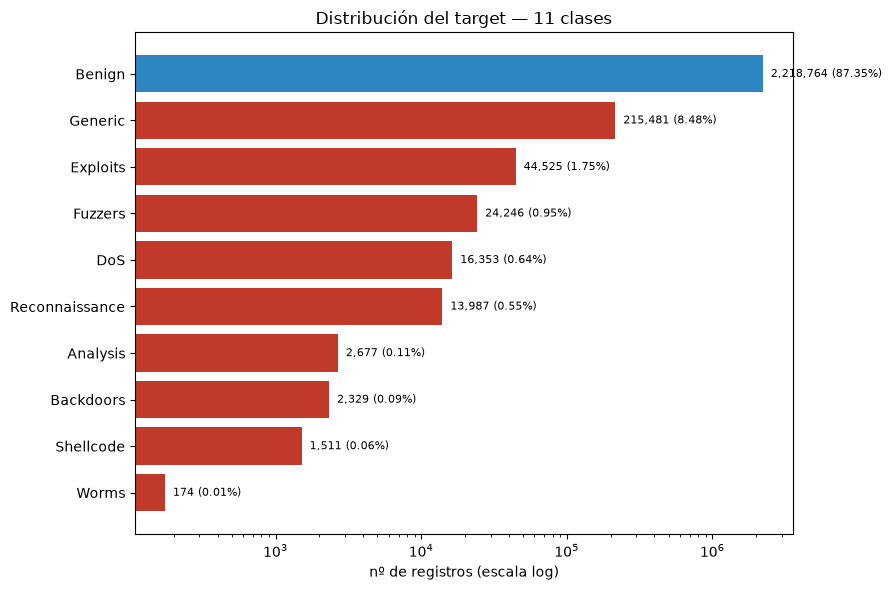

→ fig02_benigno_vs_ataque.png


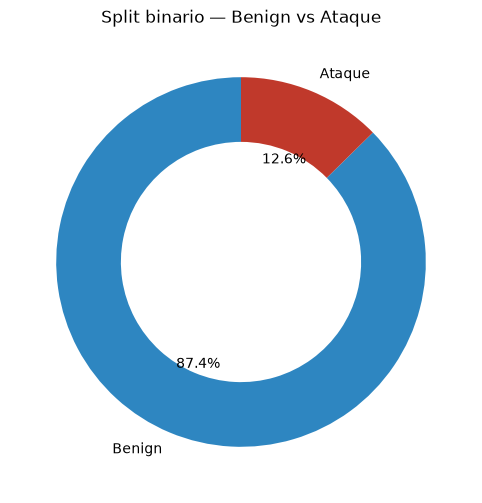

In [16]:
# fig01 — distribución del target (11 clases)
vc_asc = df["attack_cat"].value_counts().sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(vc_asc.index, vc_asc.values, color=[AZUL if c == "Benign" else ROJO for c in vc_asc.index])
ax.set_xscale("log")
ax.set_xlabel("nº de registros (escala log)")
ax.set_title("Distribución del target — 11 clases")
for y, (n, p) in enumerate(zip(vc_asc.values, vc_asc.values / len(df) * 100)):
    ax.text(n, y, f"  {n:,} ({p:.2f}%)", va="center", fontsize=8)
fig.tight_layout()
_guardar_fig(fig, "fig01_distribucion_clases.png")
plt.show()

# fig02 — split binario Benign vs Ataque
n_ben = int((df["attack_cat"] == "Benign").sum())
n_ataq = len(df) - n_ben
fig, ax = plt.subplots(figsize=(6, 6))
ax.pie([n_ben, n_ataq], labels=["Benign", "Ataque"], autopct="%.1f%%",
       colors=[AZUL, ROJO], startangle=90, wedgeprops=dict(width=0.35))
ax.set_title("Split binario — Benign vs Ataque")
_guardar_fig(fig, "fig02_benigno_vs_ataque.png")
plt.show()


→ fig03_valores_faltantes.png


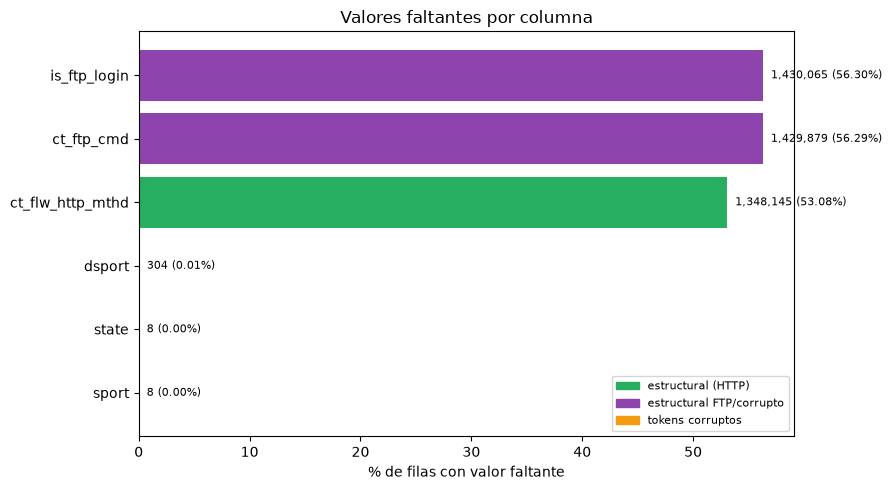

In [17]:
# fig03 — valores faltantes por columna y origen
miss = df.isna().sum()
miss = miss[miss > 0].sort_values()
origen = {
    "ct_flw_http_mthd": "estructural (HTTP)",
    "is_ftp_login": "estructural FTP/corrupto",
    "ct_ftp_cmd": "estructural FTP/corrupto",
    "sport": "tokens corruptos",
    "dsport": "tokens corruptos",
    "state": "tokens corruptos",
}
paleta = {"estructural (HTTP)": "#27ae60", "estructural FTP/corrupto": "#8e44ad",
          "tokens corruptos": "#f39c12"}
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(miss.index, miss.values / len(df) * 100,
        color=[paleta[origen[c]] for c in miss.index])
ax.set_xlabel("% de filas con valor faltante")
ax.set_title("Valores faltantes por columna")
for y, (c, n) in enumerate(miss.items()):
    ax.text(n / len(df) * 100, y, f"  {n:,} ({n / len(df) * 100:.2f}%)", va="center", fontsize=8)
ax.legend(handles=[Patch(color=v, label=k) for k, v in paleta.items()], fontsize=8, loc="lower right")
fig.tight_layout()
_guardar_fig(fig, "fig03_valores_faltantes.png")
plt.show()


→ fig04_correlacion_features.png


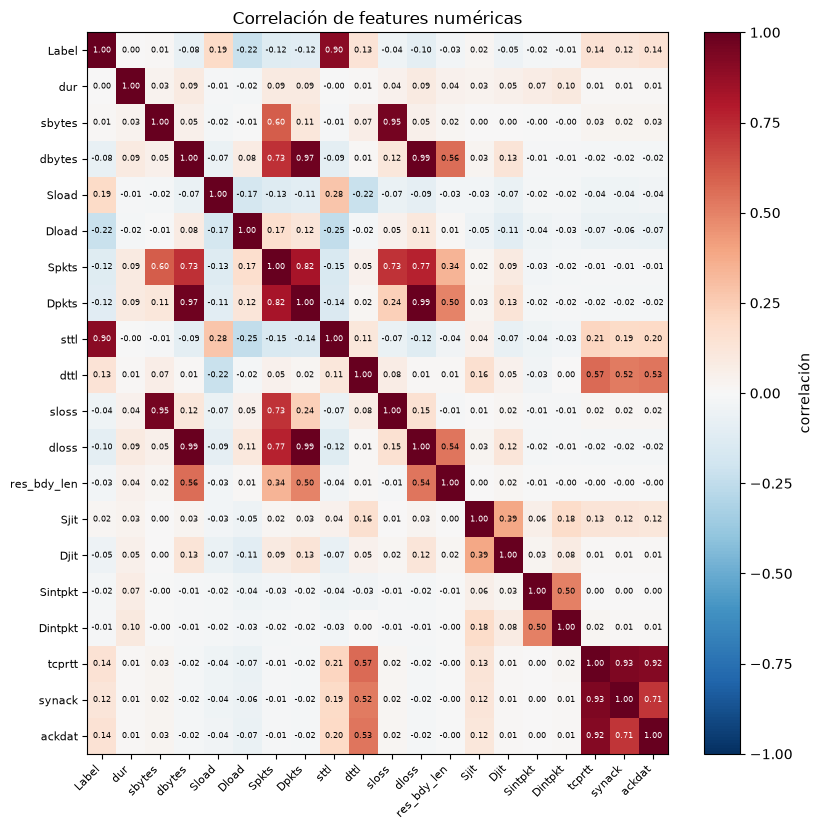

In [18]:
# fig04 — correlación de features numéricas seleccionadas
sel = ["dur", "sbytes", "dbytes", "Sload", "Dload", "Spkts", "Dpkts",
       "sttl", "dttl", "sloss", "dloss", "res_bdy_len", "Sjit", "Djit",
       "Sintpkt", "Dintpkt", "tcprtt", "synack", "ackdat"]
mat = df[["Label"] + sel].corr().values
heatmap(
  mat, ["Label"] + sel, ["Label"] + sel,
  "Correlación de features numéricas", 
  "fig04_correlacion_features.png"
)
plt.show()

→ fig05_ct_vs_target.png


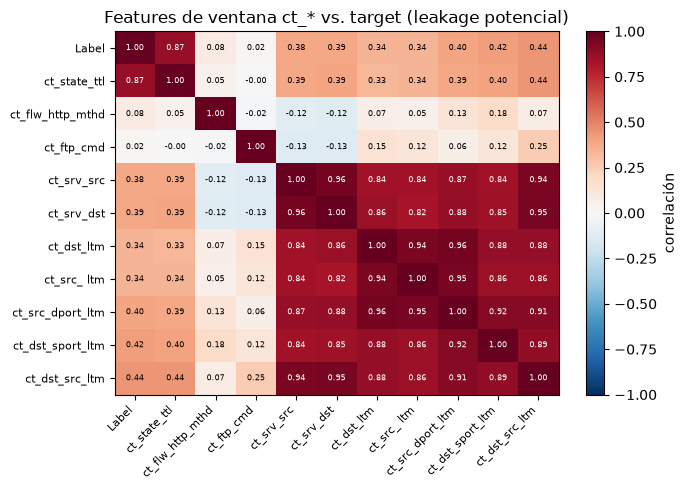

In [19]:
# fig05 — features de ventana ct_* vs target (leakage potencial)
ct_cols = ["ct_state_ttl", "ct_flw_http_mthd", "ct_ftp_cmd", "ct_srv_src",
           "ct_srv_dst", "ct_dst_ltm", "ct_src_ ltm", "ct_src_dport_ltm",
           "ct_dst_sport_ltm", "ct_dst_src_ltm"]
mat = df[["Label"] + ct_cols].corr().values
heatmap(
  mat, ["Label"] + ct_cols, ["Label"] + ct_cols,
  "Features de ventana ct_* vs. target (leakage potencial)", 
  "fig05_ct_vs_target.png"
)
plt.show()


→ fig06_histogramas_num.png


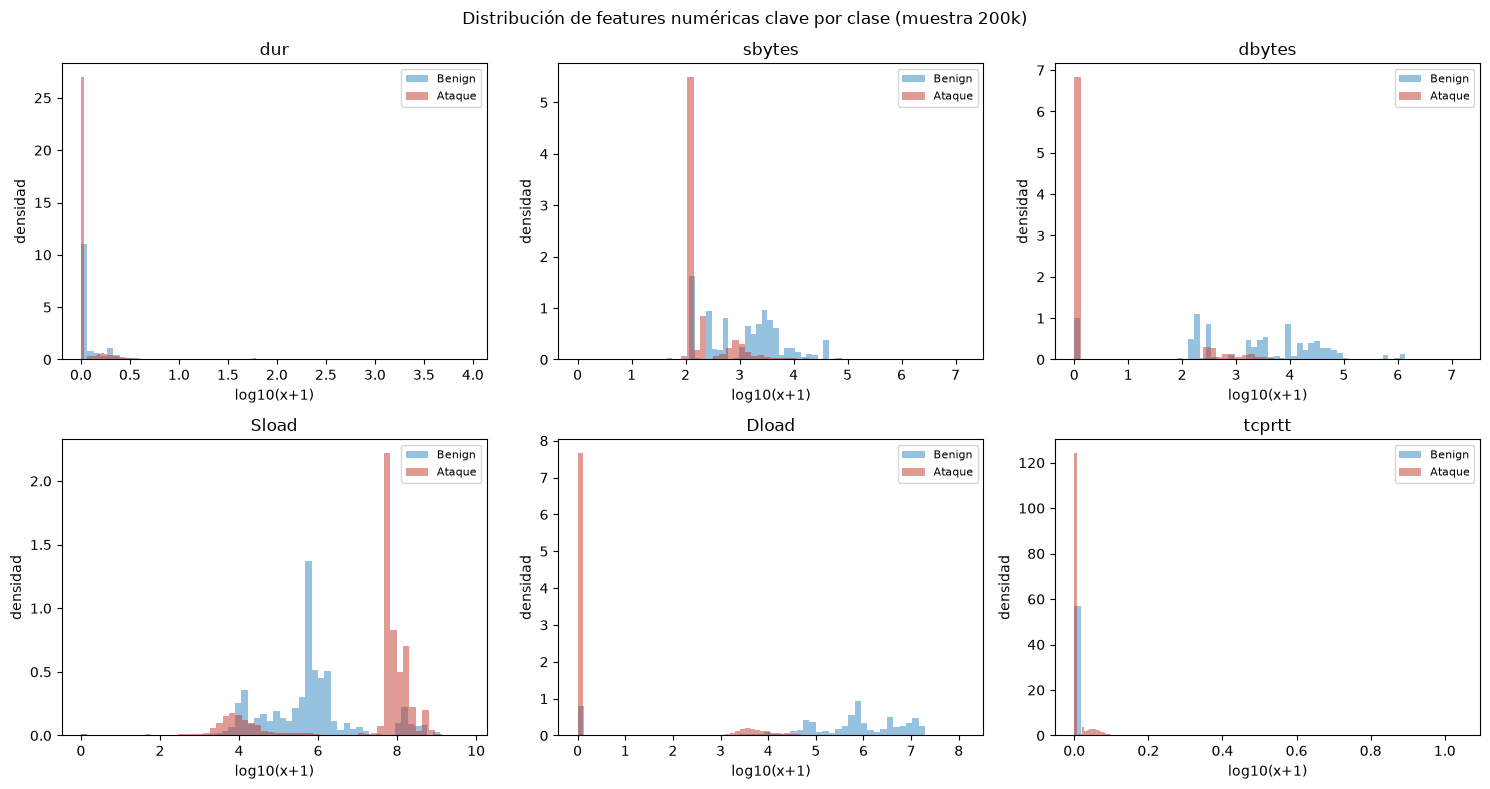

In [20]:
# fig06 — histogramas log10 de features clave, por clase
m_ben = df[df["attack_cat"] == "Benign"]
m_ataq = df[df["attack_cat"] != "Benign"]
num_hist = ["dur", "sbytes", "dbytes", "Sload", "Dload", "tcprtt"]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.ravel(), num_hist):
    ax.hist(np.log10(m_ben[col].astype("float64") + 1), bins=60, alpha=0.5,
            label="Benign", color=AZUL, density=True)
    ax.hist(np.log10(m_ataq[col].astype("float64") + 1), bins=60, alpha=0.5,
            label="Ataque", color=ROJO, density=True)
    ax.set_title(col)
    ax.set_xlabel("log10(x+1)")
    ax.set_ylabel("densidad")
    ax.legend(fontsize=8)
fig.suptitle("Distribución de features numéricas clave por clase (muestra 200k)")
fig.tight_layout()
_guardar_fig(fig, "fig06_histogramas_num.png")
plt.show()


→ fig07_nominales.png


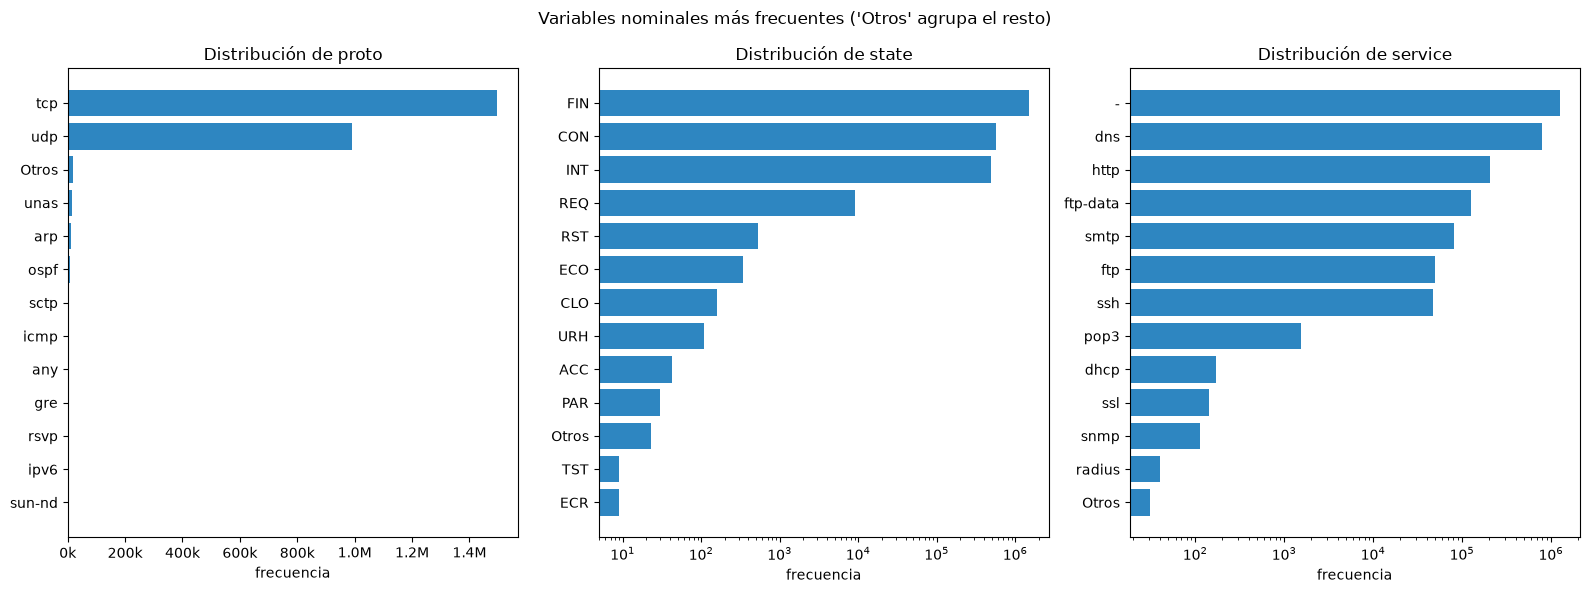

In [21]:
# fig07 — variables nominales (con 'Otros' para colas largas)
def tabla_con_otros(s, top_n=12):
    vc = s.value_counts()
    if len(vc) <= top_n:
        return vc.sort_values()
    resto = vc.iloc[top_n:].sum()
    top = vc.iloc[:top_n].sort_values()
    return pd.concat([top, pd.Series({"Otros": resto})]).sort_values()

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
for ax, col in zip(axes, ["proto", "state", "service"]):
    t = tabla_con_otros(df[col])
    ax.barh(t.index.astype(str), t.values, color=AZUL)
    ax.set_title(f"Distribución de {col}")
    ax.set_xlabel("frecuencia")
    ax.xaxis.set_major_formatter(lambda x, _: f"{x/1e6:.1f}M" if x >= 1e6 else f"{x/1e3:.0f}k")
for ax in axes[1:]:
    ax.set_xscale("log")
fig.suptitle("Variables nominales más frecuentes ('Otros' agrupa el resto)")
fig.tight_layout()
_guardar_fig(fig, "fig07_nominales.png")
plt.show()

## Resumen y siguientes pasos

Hallazgos principales del EDA:
1. **Faltantes estructurales:** `ct_flw_http_mthd`, `is_ftp_login`, `ct_ftp_cmd` (≈53–56 %)
   son NaN porque solo aplican a flujos HTTP/FTP — no es pérdida de datos.
2. **Desbalance severo:** `Benign` 87.4 % vs ataques 12.6 %; `Worms` solo 174 registros.
3. **Calidad:** 480,633 filas duplicadas (18.9 %), todas exactas — candidatas a eliminación;
   ninguna columna constante.
4. **Outliers de cola pesada:** `Sload`, `dur`, `Sjit`, etc., con alto % de ceros.
5. **Leakage a evitar en P2:** `Label` (derivable del target) y discusión sobre features de
   ventana `ct_*` y `attack_cat` como variable de entrada.